Upload your missing boundaries image or zip file:


Saving missing_boundaries_input.avif to missing_boundaries_input (2).avif


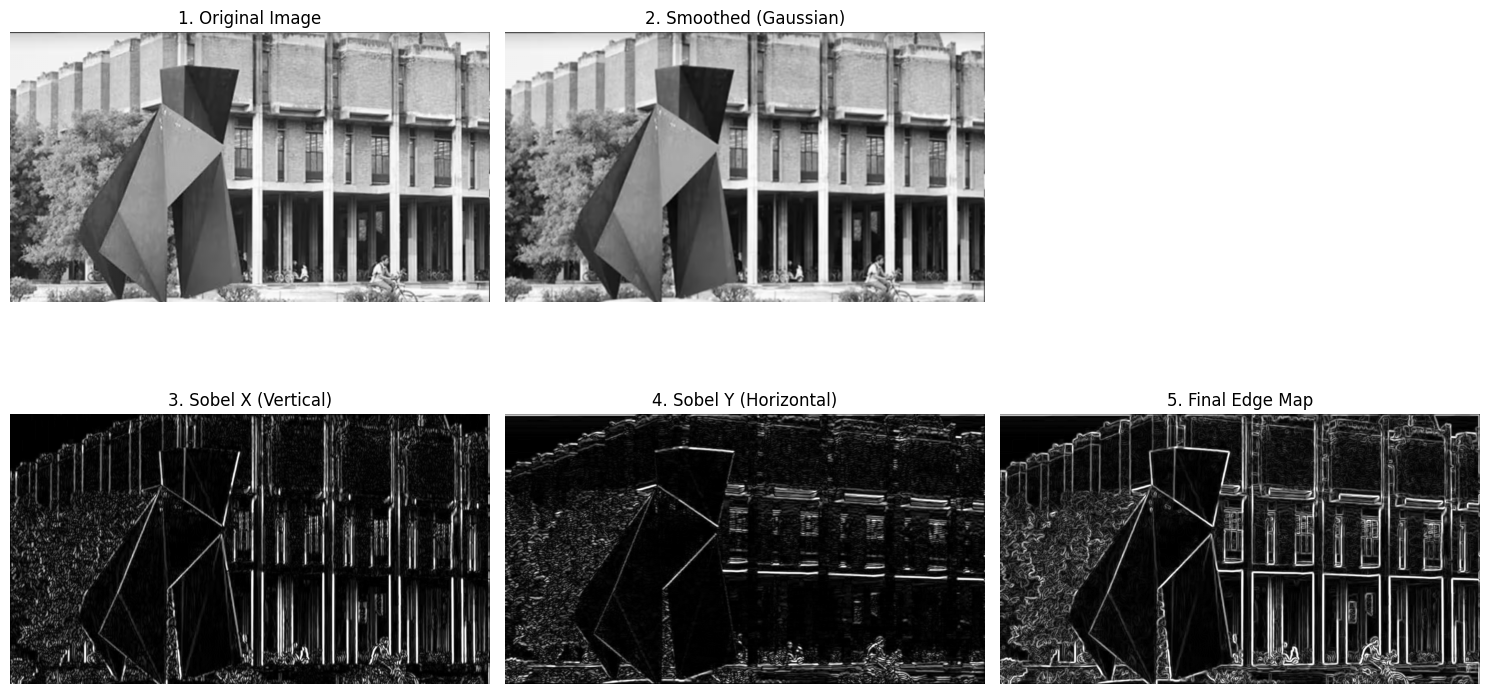

In [5]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload your missing boundaries image or zip file:")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

img_path = fname

# extract if it's a zip file
if zipfile.is_zipfile(fname):
    with zipfile.ZipFile(fname, 'r') as z:
        z.extractall("edge_files")

    # hunt for the image file
    for root, dirs, files_list in os.walk("edge_files"):
        for f in files_list:
            if "missing" in f.lower() or "boundary" in f.lower() or f.lower().endswith(('.png', '.jpg')):
                img_path = os.path.join(root, f)
                break

# load image in grayscale (0)
img = cv2.imread(img_path, 0)

if img is None:
    print("Error: Could not load image")

# apply gaussian blur to reduce background noise
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# calculate sobel derivatives (edges)
sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

# calculate overall gradient magnitude
magnitude = np.sqrt(sobelx**2 + sobely**2)

# convert back to standard 8-bit image format for displaying
sobelx_img = cv2.convertScaleAbs(sobelx)
sobely_img = cv2.convertScaleAbs(sobely)
mag_img = cv2.convertScaleAbs(magnitude)

# plot all the results
plt.figure(figsize=(15, 8))

# 1.Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('1. Original Image')
plt.axis('off')

# 2.Smoothed image
plt.subplot(2, 3, 2)
plt.imshow(blurred, cmap='gray')
plt.title('2. Smoothed (Gaussian)')
plt.axis('off')

# Empty position (optional)
plt.subplot(2, 3, 4)
plt.imshow(sobelx_img, cmap='gray')
plt.title('3. Sobel X (Vertical)')
plt.axis('off')

# 3.Sobel X output
plt.subplot(2, 3, 5)
plt.imshow(sobely_img, cmap='gray')
plt.title('4. Sobel Y (Horizontal)')
plt.axis('off')

# 4.Sobel Y output
plt.subplot(2, 3, 6)
plt.imshow(mag_img, cmap='gray')
plt.title('5. Final Edge Map')
plt.axis('off')

# 5.Combined edge map
plt.tight_layout()
plt.show()